# Requisito 4 - ambienti leggermente non stazionari, versione base

Estendo il Combinatorial-UCB del requisito 2 con sliding window e con un change detector, e li confronto con il metodo primal-dual del requisito 3.

Nota sul testo del requisito: la slide dice "pricing problem" ma descrive gli intervalli in termini di distribuzione dei massimi bid concorrenti; tengo la formulazione di bidding dei requisiti 2-3. L'istanza usa una griglia di bid non uniforme e valori diversi dal requisito 2, per costruire segmenti in cui le campagne convenienti cambiano davvero; la struttura del problema resta identica.

## Setup

30 trial appaiati: nello stesso trial tutti gli algoritmi vedono la stessa traiettoria di mercato. L'orizzonte e' diviso in tre segmenti stazionari uguali, quindi Upsilon_T = 2 e' noto per costruzione e gli iperparametri vengono dalle formule del corso.

In [1]:
import itertools
from collections import deque

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import optimize, stats

SEED = 23
T = 3000
TRIALS = 30
BUDGET = 560.0
RHO = BUDGET / T

# istanza: griglia non uniforme (piu' fitta sui bid bassi) e valori diversi dal requisito 2,
# per avere segmenti con campagne convenienti diverse; la struttura del problema e' la stessa
BID_GRID = np.array([0.0, 0.10, 0.20, 0.30, 0.40, 0.55, 0.70, 0.85])
VALUES = np.array([0.95, 0.88, 0.78, 0.92])
N_CAMPAIGNS = len(VALUES)
N_BIDS = len(BID_GRID)
CONFLICT_EDGES = [(0, 1), (1, 2), (2, 3)]

# parametri Beta(alpha, beta) del massimo bid concorrente, per campagna e per segmento
SEGMENTS = [
    [(2.0, 5.0), (3.2, 3.8), (4.1, 3.0), (2.4, 4.2)],
    [(4.8, 2.3), (2.3, 5.4), (5.0, 2.6), (3.5, 3.0)],
    [(2.4, 2.3), (5.1, 2.0), (2.2, 5.1), (4.4, 2.8)],
]
SEGMENT_LENGTHS = [T // 3, T // 3, T - 2 * (T // 3)]
CHANGE_POINTS = np.cumsum(SEGMENT_LENGTHS)[:-1]

# iperparametri dalle formule del corso, con Upsilon_T noto per costruzione
UPSILON_T = len(SEGMENTS) - 1
SW_WINDOW = int(2 * np.sqrt(T * np.log(T) / UPSILON_T))
CUSUM_ALPHA = float(np.sqrt(UPSILON_T * np.log(T / UPSILON_T) / T))
CUSUM_M = int(np.log(T / UPSILON_T))
CUSUM_H = float(2 * np.log(T / UPSILON_T))

BASE_ENV_SEED = 1000

print(f'Upsilon_T = {UPSILON_T}, W = {SW_WINDOW}, alpha = {CUSUM_ALPHA:.4f}, M = {CUSUM_M}, h = {CUSUM_H:.2f}, rho = {RHO:.4f}')

Upsilon_T = 2, W = 219, alpha = 0.0698, M = 7, h = 14.63, rho = 0.1867


## Ambiente piecewise-stationary

In ogni segmento il massimo bid concorrente della campagna i e' Beta(alpha_si, beta_si); ai change point i parametri cambiano. A ogni round il learner sceglie un bid per campagna, vince dove bid >= threshold e, in caso di vittoria, guadagna v - b e paga b. I threshold realizzati servono solo al primal-dual (full feedback, come consentito dal requisito 3).

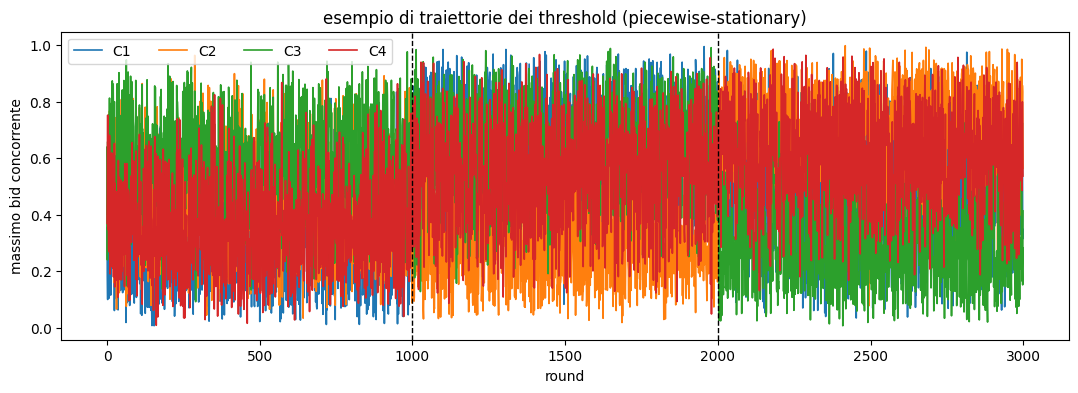

In [2]:
class PiecewiseStationaryEnv:
    # una first-price auction per campagna per round; la distribuzione dei threshold
    # cambia ai change point
    def __init__(self, seed):
        self.rng = np.random.default_rng(seed)
        self.breakpoints = np.cumsum(SEGMENT_LENGTHS)
        self.t = 0

    def draw_thresholds(self):
        segment = SEGMENTS[int(np.searchsorted(self.breakpoints, self.t, side='right'))]
        return np.array([self.rng.beta(a, b) for a, b in segment])

    def round(self, bids):
        thresholds = self.draw_thresholds()
        wins = (bids >= thresholds).astype(float)
        utilities = (VALUES - bids) * wins
        costs = bids * wins
        self.t += 1
        return thresholds, utilities, costs


env = PiecewiseStationaryEnv(seed=SEED)
example_path = np.array([env.round(np.zeros(N_CAMPAIGNS))[0] for _ in range(T)])

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(example_path, linewidth=1.2, label=[f'C{i+1}' for i in range(N_CAMPAIGNS)])
for cp in CHANGE_POINTS:
    ax.axvline(cp, color='black', linestyle='--', linewidth=1)
ax.set_title('esempio di traiettorie dei threshold (piecewise-stationary)')
ax.set_xlabel('round')
ax.set_ylabel('massimo bid concorrente')
ax.legend(ncol=4)
plt.show()

## Super-azioni e LP con budget

Un arm e' una coppia (campagna, bid); i bid sopra il valore della campagna sono dominati e vengono esclusi. Come nel requisito 2, il livello decisionale dei learner UCB risolve un LP sul simplesso delle super-azioni con vincolo di costo medio al piu' rho = B/T.

In [3]:
superaction_bid_indices = np.array([
    idxs for idxs in itertools.product(range(N_BIDS), repeat=N_CAMPAIGNS)
    if all(BID_GRID[idxs[i]] == 0 or BID_GRID[idxs[i]] <= VALUES[i] for i in range(N_CAMPAIGNS))
    and all(not (BID_GRID[idxs[i]] > 0 and BID_GRID[idxs[j]] > 0) for i, j in CONFLICT_EDGES)
])
bids_matrix = BID_GRID[superaction_bid_indices]
bid_sums = bids_matrix.sum(axis=1)
K = len(superaction_bid_indices)
NULL_IDX = int(np.flatnonzero(bid_sums == 0)[0])

# arm giocabili: bid positivo e non dominato (bid <= valore della campagna)
PLAYABLE = (BID_GRID[None, :] > 0) & (BID_GRID[None, :] <= VALUES[:, None])
MAX_REWARD = np.maximum(VALUES[:, None] - BID_GRID[None, :], 0.0) * PLAYABLE
CAMPAIGN_IDX = np.arange(N_CAMPAIGNS)

# super-azione che gioca un singolo arm da solo, per i pull forzati
single_arm_superaction = np.full((N_CAMPAIGNS, N_BIDS), -1, dtype=int)
for k, idxs in enumerate(superaction_bid_indices):
    positive = [(i, b) for i, b in enumerate(idxs) if PLAYABLE[i, b]]
    if len(positive) == 1:
        single_arm_superaction[positive[0][0], positive[0][1]] = k


def superaction_totals(arm_matrix):
    # somma sui singoli arm contenuti in ogni super-azione (bid 0 contribuisce 0)
    masked = arm_matrix * PLAYABLE
    return masked[CAMPAIGN_IDX, superaction_bid_indices].sum(axis=1)


def solve_budget_lp(scores, costs, rho, remaining_budget):
    # LP sul simplesso delle super-azioni con vincolo di costo medio <= rho;
    # le super-azioni non pagabili hanno probabilita' zero tramite i bounds
    feasible = bid_sums <= remaining_budget + 1e-12
    gamma = np.zeros(K)
    if not feasible.any():
        gamma[NULL_IDX] = 1.0
        return gamma
    bounds = [(0.0, 1.0) if feasible[k] else (0.0, 0.0) for k in range(K)]
    res = optimize.linprog(-scores, A_ub=[costs], b_ub=[rho],
                           A_eq=[np.ones(K)], b_eq=[1.0], bounds=bounds,
                           method='highs')
    if (not res.success) or res.x is None:
        gamma[NULL_IDX] = 1.0
        return gamma
    g = np.clip(res.x, 0.0, None)
    return g / g.sum()


print(f'super-azioni ammissibili: {K}, arm positivi: {int(PLAYABLE.sum())}')

super-azioni ammissibili: 168, arm positivi: 27


## Benchmark

L'oracle segment-local risolve un LP per segmento con lo stesso budget per round B/T: e' il clairvoyant per round del caso non stazionario ed e' il benchmark principale. L'oracle segment-global usa un unico budget globale e puo' spostarlo tra segmenti: piu' forte, riportato come riferimento.

In [4]:
def expected_outcomes(segment):
    # reward e costo attesi di ogni super-azione: P(vincere con bid b) = CDF Beta in b
    win_prob = np.stack([stats.beta.cdf(bids_matrix[:, i], a, b)
                         for i, (a, b) in enumerate(segment)], axis=1)
    rewards = ((VALUES - bids_matrix) * win_prob).sum(axis=1)
    costs = (bids_matrix * win_prob).sum(axis=1)
    return rewards, costs


SEG_REWARDS, SEG_COSTS = map(np.array, zip(*[expected_outcomes(s) for s in SEGMENTS]))

def solve_segment_lp(rewards, costs, rho):
    res = optimize.linprog(-rewards, A_ub=[costs], b_ub=[rho],
                           A_eq=[np.ones(K)], b_eq=[1.0], bounds=(0, 1), method='highs')
    return res.x, float(-res.fun), float(costs @ res.x)


# oracle segment-local: un LP per segmento con lo stesso budget per round B/T (benchmark principale)
local_seg_rewards = np.array([solve_segment_lp(SEG_REWARDS[s], SEG_COSTS[s], RHO)[1]
                              for s in range(len(SEGMENTS))])
local_reward_path = np.concatenate([np.full(L, local_seg_rewards[s])
                                    for s, L in enumerate(SEGMENT_LENGTHS)])
local_cum = np.cumsum(local_reward_path)

# oracle segment-global: un unico LP con budget globale, puo' spostare budget tra segmenti
lengths = np.repeat(SEGMENT_LENGTHS, K)
res = optimize.linprog(
    -(lengths * SEG_REWARDS.reshape(-1)),
    A_ub=[(lengths * SEG_COSTS.reshape(-1))], b_ub=[BUDGET],
    A_eq=np.kron(np.eye(len(SEGMENTS)), np.ones(K)), b_eq=np.ones(len(SEGMENTS)),
    bounds=(0, 1), method='highs')
global_policy = res.x.reshape(len(SEGMENTS), K)
global_seg_rewards = np.array([global_policy[s] @ SEG_REWARDS[s] for s in range(len(SEGMENTS))])
global_reward_path = np.concatenate([np.full(L, global_seg_rewards[s])
                                     for s, L in enumerate(SEGMENT_LENGTHS)])
global_cum = np.cumsum(global_reward_path)

print(f'valore atteso oracle segment-local:  {local_cum[-1]:.1f}')
print(f'valore atteso oracle segment-global: {global_cum[-1]:.1f}')

valore atteso oracle segment-local:  1228.6
valore atteso oracle segment-global: 1252.0


## SW-UCB e CUSUM-UCB combinatori

Entrambi stimano reward e costo di ogni arm positivo e passano all'LP reward UCB e costo LCB, con rho = B/T fisso.

SW-UCB tiene le osservazioni degli ultimi W round in una cache per round, con W = 2 sqrt(T log T / Upsilon_T) e bonus basato su log(W). CUSUM-UCB raccoglie M campioni di riferimento per arm, poi una statistica CUSUM monitora i cambi; ai reset l'arm viene forzato per altri M campioni. Parametri dalle formule del corso: M = log(T/Upsilon_T), h = 2 log(T/Upsilon_T), alpha = sqrt(Upsilon_T log(T/Upsilon_T)/T).

In [5]:
class SWCombUCBAgent:
    # Combinatorial-UCB con sliding window sui round: tengo in cache le osservazioni
    # degli ultimi W round e ricalcolo medie e bonus solo su quelle
    def __init__(self, seed, W=SW_WINDOW):
        self.W = int(W)
        self.reward_cache = np.full((self.W, N_CAMPAIGNS, N_BIDS), np.nan)
        self.cost_cache = np.full((self.W, N_CAMPAIGNS, N_BIDS), np.nan)
        self.remaining_budget = BUDGET
        self.rng = np.random.default_rng(seed)
        self.k_t = NULL_IDX

    def pull_arm(self):
        obs_mask = ~np.isnan(self.reward_cache)
        n_obs = obs_mask.sum(axis=0)
        unseen = np.argwhere((n_obs == 0) & PLAYABLE & (BID_GRID[None, :] <= self.remaining_budget))
        if len(unseen) > 0:
            # arm senza osservazioni nella finestra: lo gioco una volta da solo
            i, b = unseen[self.rng.integers(len(unseen))]
            self.k_t = int(single_arm_superaction[i, b])
            return bids_matrix[self.k_t]

        seen = n_obs > 0
        sum_r = np.nansum(self.reward_cache, axis=0)
        sum_c = np.nansum(self.cost_cache, axis=0)
        avg_r = np.divide(sum_r, n_obs, out=np.zeros_like(sum_r), where=seen)
        avg_c = np.divide(sum_c, n_obs, out=np.zeros_like(sum_c), where=seen)
        conf = np.sqrt(2 * np.log(self.W) / np.maximum(n_obs, 1))
        reward_ucb = np.where(seen, avg_r + MAX_REWARD * conf, 0.0)
        cost_lcb = np.where(seen, np.maximum(avg_c - BID_GRID[None, :] * conf, 0.0), 0.0)
        gamma = solve_budget_lp(superaction_totals(reward_ucb), superaction_totals(cost_lcb),
                                RHO, self.remaining_budget)
        self.k_t = int(self.rng.choice(K, p=gamma))
        return bids_matrix[self.k_t]

    def update(self, utilities, costs):
        new_r = np.full((N_CAMPAIGNS, N_BIDS), np.nan)
        new_c = np.full((N_CAMPAIGNS, N_BIDS), np.nan)
        for i, b in enumerate(superaction_bid_indices[self.k_t]):
            if PLAYABLE[i, b]:
                new_r[i, b] = utilities[i]
                new_c[i, b] = costs[i]
        self.reward_cache = np.concatenate([self.reward_cache[1:], new_r[None]])
        self.cost_cache = np.concatenate([self.cost_cache[1:], new_c[None]])
        self.remaining_budget = max(0.0, self.remaining_budget - costs.sum())


class CUSUMCombUCBAgent:
    # Combinatorial-UCB con un detector CUSUM per arm: i primi M campioni costruiscono
    # la media di riferimento, poi la statistica monitora gli scostamenti; al reset
    # l'arm riparte da zero
    def __init__(self, seed, M=CUSUM_M, h=CUSUM_H, alpha=CUSUM_ALPHA):
        self.M = int(M)
        self.h = float(h)
        self.alpha = float(alpha)
        self.sum_r = np.zeros((N_CAMPAIGNS, N_BIDS))
        self.sum_c = np.zeros((N_CAMPAIGNS, N_BIDS))
        self.n_obs = np.zeros((N_CAMPAIGNS, N_BIDS))
        self.reference_samples = [[[] for _ in range(N_BIDS)] for _ in range(N_CAMPAIGNS)]
        self.reference = np.full((N_CAMPAIGNS, N_BIDS), np.nan)
        self.g_plus = np.zeros((N_CAMPAIGNS, N_BIDS))
        self.g_minus = np.zeros((N_CAMPAIGNS, N_BIDS))
        self.counters = np.where(PLAYABLE, self.M, 0)
        self.reset_times = []
        self.remaining_budget = BUDGET
        self.rng = np.random.default_rng(seed)
        self.t = 0
        self.k_t = NULL_IDX

    def pull_arm(self):
        forced = np.argwhere((self.counters > 0) & PLAYABLE & (BID_GRID[None, :] <= self.remaining_budget))
        if len(forced) > 0:
            # servono M campioni per la media di riferimento dell'arm
            i, b = forced[0]
            self.counters[i, b] -= 1
            self.k_t = int(single_arm_superaction[i, b])
            return bids_matrix[self.k_t]

        if self.rng.random() < self.alpha:
            # esplorazione extra con probabilita' alpha
            affordable = np.argwhere(PLAYABLE & (BID_GRID[None, :] <= self.remaining_budget))
            if len(affordable) > 0:
                i, b = affordable[self.rng.integers(len(affordable))]
                self.k_t = int(single_arm_superaction[i, b])
                return bids_matrix[self.k_t]

        seen = self.n_obs > 0
        avg_r = np.divide(self.sum_r, self.n_obs, out=np.zeros_like(self.sum_r), where=seen)
        avg_c = np.divide(self.sum_c, self.n_obs, out=np.zeros_like(self.sum_c), where=seen)
        conf = np.sqrt(np.log(max(2, self.t + 1)) / np.maximum(self.n_obs, 1))
        reward_ucb = np.where(seen, avg_r + MAX_REWARD * conf, 0.0)
        cost_lcb = np.where(seen, np.maximum(avg_c - BID_GRID[None, :] * conf, 0.0), 0.0)
        gamma = solve_budget_lp(superaction_totals(reward_ucb), superaction_totals(cost_lcb),
                                RHO, self.remaining_budget)
        self.k_t = int(self.rng.choice(K, p=gamma))
        return bids_matrix[self.k_t]

    def update(self, utilities, costs):
        for i, b in enumerate(superaction_bid_indices[self.k_t]):
            if not PLAYABLE[i, b]:
                continue

            self.sum_r[i, b] += utilities[i]
            self.sum_c[i, b] += costs[i]
            self.n_obs[i, b] += 1
            x = utilities[i] / MAX_REWARD[i, b]   # x e' l'indicatore di vittoria (0/1): il CUSUM lavora su una Bernoulli, come nel lab 10

            if np.isnan(self.reference[i, b]):
                self.reference_samples[i][b].append(x)
                if len(self.reference_samples[i][b]) >= self.M:
                    self.reference[i, b] = float(np.mean(self.reference_samples[i][b]))
                    self.reference_samples[i][b] = []
            else:
                self.g_plus[i, b] = max(0.0, self.g_plus[i, b] + x - self.reference[i, b])
                self.g_minus[i, b] = max(0.0, self.g_minus[i, b] + self.reference[i, b] - x)
                if max(self.g_plus[i, b], self.g_minus[i, b]) >= self.h:
                    # reset dell'arm: statistiche azzerate e M nuovi campioni forzati
                    self.sum_r[i, b] = 0.0
                    self.sum_c[i, b] = 0.0
                    self.n_obs[i, b] = 0.0
                    self.reference_samples[i][b] = []
                    self.reference[i, b] = np.nan
                    self.g_plus[i, b] = 0.0
                    self.g_minus[i, b] = 0.0
                    self.counters[i, b] = self.M
                    self.reset_times.append((self.t, i))

        self.remaining_budget = max(0.0, self.remaining_budget - costs.sum())
        self.t += 1

## Primal-dual (full feedback)

E' il metodo primal-dual del requisito 3 nella versione base (costanti del lab), con due adattamenti al caso combinatorio: la normalizzazione dei guadagni Lagrangiani in [0,1] con i bound veri della super-azione e il controllo del budget per azione. Tiene tutta la storia, quindi e' meno reattivo su un ambiente a segmenti.

In [6]:
def full_feedback_outcomes(thresholds):
    # reward e costo di ogni super-azione su un round realizzato
    wins = (bids_matrix >= thresholds).astype(float)
    rewards = ((VALUES - bids_matrix) * wins).sum(axis=1)
    costs = (bids_matrix * wins).sum(axis=1)
    return rewards, costs


MAX_ROUND_REWARD = float(superaction_totals(MAX_REWARD).max())
MAX_ROUND_COST = float(bid_sums.max())
PD_LAMBDA_MAX = 1.0 / RHO
PD_PRIMAL_ETA = float(np.sqrt(np.log(K) / T))       # passo Hedge del lab
PD_DUAL_ETA = 1.0 / np.sqrt(T)                       # passo OGD del lab
# una super-azione somma piu' campagne, quindi f - lambda*c esce da [0,1]:
# normalizzo i guadagni con i bound veri per usare Hedge come nel lab
GAIN_LOW = -PD_LAMBDA_MAX * MAX_ROUND_COST
GAIN_RANGE = MAX_ROUND_REWARD + PD_LAMBDA_MAX * MAX_ROUND_COST
print(f'eta Hedge = {PD_PRIMAL_ETA:.4f}, eta OGD = {PD_DUAL_ETA:.4f}, lambda_max = {PD_LAMBDA_MAX:.3f}')


class PrimalDualAgent:
    # primal-dual del requisito 3 (versione base, costanti del lab): Hedge sulle super-azioni,
    # OGD proiettato sul duale, full feedback
    def __init__(self, seed):
        self.scores = np.zeros(K)      # somma dei guadagni Lagrangiani normalizzati
        self.lmbd = 1.0
        self.remaining_budget = BUDGET
        self.rng = np.random.default_rng(seed)
        self.x_t = np.zeros(K)
        self.k_t = NULL_IDX
        self.lambda_history = []

    def pull_arm(self):
        weights = np.exp(PD_PRIMAL_ETA * (self.scores - self.scores.max()))
        self.x_t = weights / weights.sum()
        k = int(self.rng.choice(K, p=self.x_t))
        if bid_sums[k] > self.remaining_budget:   # controllo per azione
            k = NULL_IDX
        self.k_t = k
        return bids_matrix[k]

    def update(self, thresholds, costs):
        rewards_all, costs_all = full_feedback_outcomes(thresholds)
        gains = rewards_all - self.lmbd * costs_all
        self.scores += (gains - GAIN_LOW) / GAIN_RANGE
        expected_cost = float(costs_all @ self.x_t)
        self.lmbd = float(np.clip(self.lmbd + PD_DUAL_ETA * (expected_cost - RHO), 0.0, PD_LAMBDA_MAX))
        self.remaining_budget = max(0.0, self.remaining_budget - costs.sum())
        self.lambda_history.append(self.lmbd)

eta Hedge = 0.0413, eta OGD = 0.0183, lambda_max = 5.357


## Simulazione

In [7]:
AGENT_NAMES = ['sw_ucb', 'cusum_ucb', 'pd_full']
LABELS = {'sw_ucb': 'SW Combinatorial-UCB', 'cusum_ucb': 'CUSUM Combinatorial-UCB',
          'pd_full': 'Primal-dual (full feedback)'}
COLORS = {'sw_ucb': 'tab:blue', 'cusum_ucb': 'tab:orange', 'pd_full': 'tab:green'}
AGENTS = {'sw_ucb': SWCombUCBAgent, 'cusum_ucb': CUSUMCombUCBAgent, 'pd_full': PrimalDualAgent}
AGENT_SEED_OFFSETS = {'sw_ucb': 10_000, 'cusum_ucb': 20_000, 'pd_full': 30_000}

In [8]:
def run_trial(agent_kind, env_seed, agent_seed):
    env = PiecewiseStationaryEnv(seed=env_seed)
    agent = AGENTS[agent_kind](agent_seed)

    rewards = np.zeros(T)
    round_costs = np.zeros(T)
    bid_log = np.zeros((T, N_CAMPAIGNS))
    for t in range(T):
        bids = agent.pull_arm()
        thresholds, utilities, costs = env.round(bids)
        if agent_kind.startswith('pd'):
            agent.update(thresholds, costs)      # full feedback
        else:
            agent.update(utilities, costs)       # feedback semi-bandit
        rewards[t] = utilities.sum()
        round_costs[t] = costs.sum()
        bid_log[t] = bids

    out = {'cum_rewards': np.cumsum(rewards), 'cum_costs': np.cumsum(round_costs), 'bids': bid_log}
    if agent_kind == 'cusum_ucb':
        out['reset_times'] = list(agent.reset_times)
    if agent_kind.startswith('pd'):
        out['lambda'] = np.array(agent.lambda_history)
    return out


results = {}
for name in AGENT_NAMES:
    results[name] = []
    for j in range(TRIALS):
        results[name].append(run_trial(name, BASE_ENV_SEED + j, BASE_ENV_SEED + j + AGENT_SEED_OFFSETS[name]))

for name, runs in results.items():
    assert all(run['cum_costs'][-1] <= BUDGET + 1e-9 for run in runs), f'{name} viola il budget'
print('simulazioni completate, budget rispettato in ogni trial')

simulazioni completate, budget rispettato in ogni trial


## Risultati

In [9]:
utility = {name: np.vstack([run['cum_rewards'] for run in results[name]]) for name in AGENT_NAMES}
spend = {name: np.vstack([run['cum_costs'] for run in results[name]]) for name in AGENT_NAMES}
local_gap = {name: local_cum[None, :] - utility[name] for name in AGENT_NAMES}
global_gap = {name: global_cum[None, :] - utility[name] for name in AGENT_NAMES}


def mean_sem(matrix):
    return matrix.mean(axis=0), matrix.std(axis=0, ddof=1) / np.sqrt(matrix.shape[0])


rows = []
for name in AGENT_NAMES:
    lg, lg_sem = mean_sem(local_gap[name][:, -1:])
    gg, _ = mean_sem(global_gap[name][:, -1:])
    u, u_sem = mean_sem(utility[name][:, -1:])
    s, _ = mean_sem(spend[name][:, -1:])
    rows.append({'algoritmo': LABELS[name],
                 'gap locale': lg[0], 'gap locale SEM': lg_sem[0],
                 'gap globale': gg[0],
                 'utility': u[0], 'utility SEM': u_sem[0],
                 'spesa': s[0], 'budget residuo': BUDGET - s[0]})
pd.DataFrame(rows).round(2)

,algoritmo,gap locale,gap locale SEM,gap globale,utility,utility SEM,spesa,budget residuo
0,SW Combinatorial-UCB,561.99,2.25,585.46,666.56,2.25,559.98,0.02
1,CUSUM Combinatorial-UCB,533.30,5.10,556.76,695.25,5.10,559.97,0.03
2,Primal-dual (full feedback),715.78,2.55,739.25,512.77,2.55,393.41,166.59


In [10]:
checkpoints = [500, 1000, 2000, 3000]
rows = []
for name in AGENT_NAMES:
    row = {'algoritmo': LABELS[name]}
    for c in checkpoints:
        row[f'R_{c}/t (locale)'] = local_gap[name].mean(axis=0)[c - 1] / c
    rows.append(row)
pd.DataFrame(rows).round(4)

,algoritmo,R_500/t (locale),R_1000/t (locale),R_2000/t (locale),R_3000/t (locale)
0,SW Combinatorial-UCB,0.0875,0.0800,0.1116,0.1873
1,CUSUM Combinatorial-UCB,0.1093,0.0288,0.0904,0.1778
2,Primal-dual (full feedback),0.1894,0.2106,0.2455,0.2386


## Diagnostica CUSUM

Numero di reset e loro posizione rispetto ai change point veri.

reset medi per trial: 18.2 (2 change point x 27 arm = 54, riferimento: un reset per arm per change point)


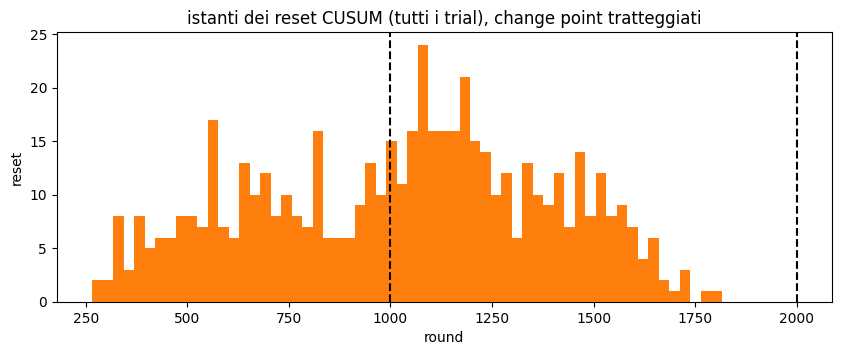

In [11]:
all_reset_times = [t for run in results['cusum_ucb'] for (t, i) in run['reset_times']]
mean_resets = np.mean([len(run['reset_times']) for run in results['cusum_ucb']])
n_positive_arms = int(PLAYABLE.sum())
print(f'reset medi per trial: {mean_resets:.1f} '
      f'({UPSILON_T} change point x {n_positive_arms} arm = {UPSILON_T * n_positive_arms}, riferimento: un reset per arm per change point)')

if all_reset_times:
    fig, ax = plt.subplots(figsize=(10, 3.5))
    ax.hist(all_reset_times, bins=60, color='tab:orange')
    for cp in CHANGE_POINTS:
        ax.axvline(cp, color='black', linestyle='--', linewidth=1.5)
    ax.set_title('istanti dei reset CUSUM (tutti i trial), change point tratteggiati')
    ax.set_xlabel('round')
    ax.set_ylabel('reset')
    plt.show()

## Grafici

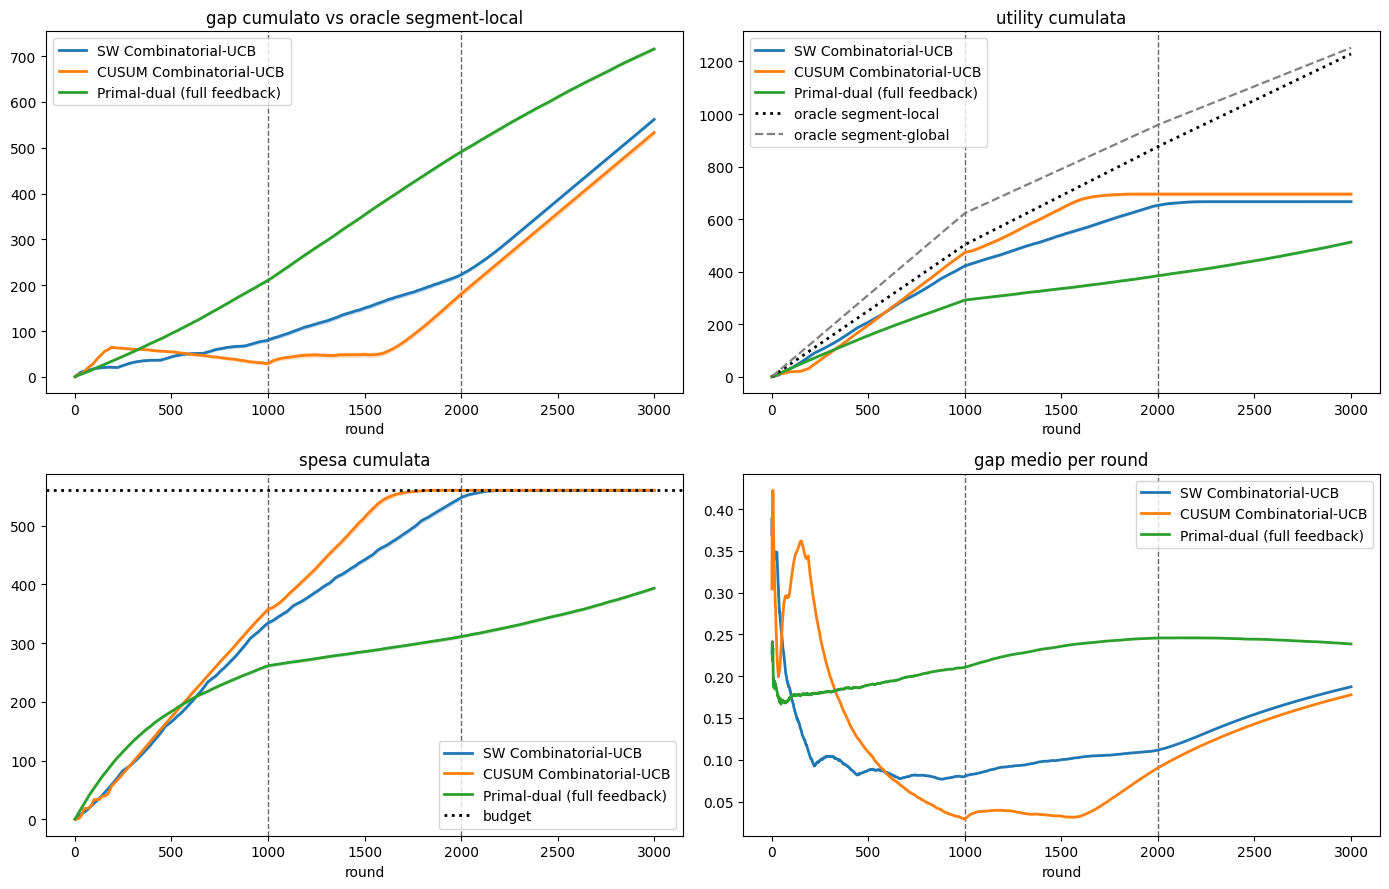

In [12]:
x = np.arange(1, T + 1)
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax in axes.ravel():
    for cp in CHANGE_POINTS:
        ax.axvline(cp, color='black', linestyle='--', linewidth=1, alpha=0.6)

for name in AGENT_NAMES:
    m, sem = mean_sem(local_gap[name])
    axes[0, 0].plot(x, m, linewidth=2, color=COLORS[name], label=LABELS[name])
    axes[0, 0].fill_between(x, m - sem, m + sem, color=COLORS[name], alpha=0.18)
axes[0, 0].set_title('gap cumulato vs oracle segment-local')
axes[0, 0].set_xlabel('round')
axes[0, 0].legend()

for name in AGENT_NAMES:
    m, sem = mean_sem(utility[name])
    axes[0, 1].plot(x, m, linewidth=2, color=COLORS[name], label=LABELS[name])
    axes[0, 1].fill_between(x, m - sem, m + sem, color=COLORS[name], alpha=0.18)
axes[0, 1].plot(x, local_cum, color='black', linestyle=':', linewidth=2, label='oracle segment-local')
axes[0, 1].plot(x, global_cum, color='gray', linestyle='--', linewidth=1.6, label='oracle segment-global')
axes[0, 1].set_title('utility cumulata')
axes[0, 1].set_xlabel('round')
axes[0, 1].legend()

for name in AGENT_NAMES:
    m, sem = mean_sem(spend[name])
    axes[1, 0].plot(x, m, linewidth=2, color=COLORS[name], label=LABELS[name])
    axes[1, 0].fill_between(x, m - sem, m + sem, color=COLORS[name], alpha=0.18)
axes[1, 0].axhline(BUDGET, color='black', linestyle=':', linewidth=2, label='budget')
axes[1, 0].set_title('spesa cumulata')
axes[1, 0].set_xlabel('round')
axes[1, 0].legend()

for name in AGENT_NAMES:
    m, _ = mean_sem(local_gap[name])
    axes[1, 1].plot(x, m / x, linewidth=2, color=COLORS[name], label=LABELS[name])
axes[1, 1].set_title('gap medio per round')
axes[1, 1].set_xlabel('round')
axes[1, 1].legend()

fig.tight_layout()
plt.show()

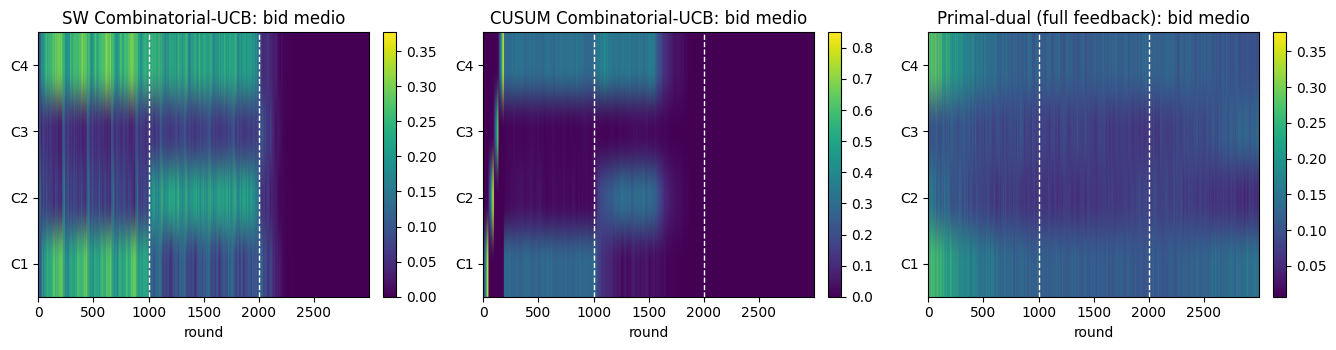

In [13]:
n_cols = len(AGENT_NAMES)
fig, axes = plt.subplots(1, n_cols, figsize=(4.5 * n_cols, 3.6))
for col, name in enumerate(AGENT_NAMES):
    mean_bid = np.stack([run['bids'] for run in results[name]]).mean(axis=0).T
    im = axes[col].imshow(mean_bid, aspect='auto', origin='lower', cmap='viridis')
    for cp in CHANGE_POINTS:
        axes[col].axvline(cp, color='white', linestyle='--', linewidth=1)
    axes[col].set_title(f'{LABELS[name]}: bid medio')
    axes[col].set_xlabel('round')
    axes[col].set_yticks(range(N_CAMPAIGNS))
    axes[col].set_yticklabels([f'C{i+1}' for i in range(N_CAMPAIGNS)])
    fig.colorbar(im, ax=axes[col], fraction=0.046, pad=0.04)
fig.tight_layout()
plt.show()

## Osservazioni finali

Questa versione resta sulle scelte del corso: rho = B/T fisso, SW-UCB con finestra sui round, CUSUM-UCB con i parametri delle formule del corso, reward UCB e costo LCB, primal-dual del requisito 3 con le costanti del lab.

Tre cose emergono dai numeri. Primo, il gap medio per round a fine orizzonte resta alto per tutti (SW 0.187, CUSUM 0.178, primal-dual 0.239). Secondo, i due UCB spendono l'intero budget ma lo esauriscono in anticipo (stessa dinamica del requisito 2: costo LCB + rho fisso), mentre il primal-dual lascia 167 su 560 inutilizzati perche' tiene tutta la storia e resta conservativo. Terzo, il CUSUM con i parametri del corso scatta poco (~18 reset per trial contro un riferimento di ~54, un reset per arm per change point): con ~27 arm che si dividono i round, ogni arm accumula pochi campioni tra un change point e l'altro e la soglia h = 14.6 viene raggiunta raramente. Sono i tre punti su cui interviene la versione migliorata.